In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

In [2]:
pwd

'/Users/tarunluthra/Documents/amperon'

In [4]:
cwd = '/Users/tarunluthra/Documents/amperon'
# Load the uploaded files
load_hist = pd.read_csv(f"{cwd}/load_hist_data.csv")
weather = pd.read_csv(f"{cwd}/weather_data.csv")
prob_estimates = pd.read_csv(f"{cwd}/probability_estimates.csv")

# Check the first few rows and basic info of each
load_hist_info = load_hist.info()
weather_info = weather.info()
prob_estimates_info = prob_estimates.info()

load_hist_head = load_hist.head()
weather_head = weather.head()
prob_estimates_head = prob_estimates.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26280 entries, 0 to 26279
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    26280 non-null  object
 1   Hour    26280 non-null  int64 
 2   Load    26280 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 616.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 981792 entries, 0 to 981791
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Date         981792 non-null  object
 1   Hour         981792 non-null  int64 
 2   Station ID   981792 non-null  int64 
 3   Temperature  981792 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 30.0+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Date                    8784 n

In [6]:
( load_hist_head,
  weather_head,
  prob_estimates_head)

(       Date  Hour  Load
 0  1/1/2005     1   857
 1  1/1/2005     2   825
 2  1/1/2005     3   800
 3  1/1/2005     4   794
 4  1/1/2005     5   802,
        Date  Hour  Station ID  Temperature
 0  1/1/2005     1           1           43
 1  1/1/2005     2           1           41
 2  1/1/2005     3           1           40
 3  1/1/2005     4           1           39
 4  1/1/2005     5           1           38,
        Date  Hour  Daily Peak Probability
 0  1/1/2008     1                     NaN
 1  1/1/2008     2                     NaN
 2  1/1/2008     3                     NaN
 3  1/1/2008     4                     NaN
 4  1/1/2008     5                     NaN)

In [8]:
# ---- Parse and enrich ----
def parse_date(df, date_col="Date"):
    df = df.copy()
    df["Date_dt"] = pd.to_datetime(df[date_col], infer_datetime_format=True, errors="coerce")
    return df

load_hist = parse_date(load_hist, "Date")

# Extract calendar fields
load_hist["Year"] = load_hist["Date_dt"].dt.year
load_hist["Month"] = load_hist["Date_dt"].dt.month
load_hist["Day"] = load_hist["Date_dt"].dt.day
load_hist["Weekday"] = load_hist["Date_dt"].dt.weekday  # Monday=0, Sunday=6
load_hist["IsWeekend"] = load_hist["Weekday"] >= 5

/var/folders/lf/9_7wh6ps1354b6glt9mst87m0000gn/T/ipykernel_49322/4286571273.py:4: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df["Date_dt"] = pd.to_datetime(df[date_col], infer_datetime_format=True, errors="coerce")


In [9]:
# ---- Parse and enrich ----
def parse_date(df, date_col="Date"):
    df = df.copy()
    df["Date_dt"] = pd.to_datetime(df[date_col], infer_datetime_format=True, errors="coerce")
    return df

load_hist = parse_date(load_hist, "Date")

# Extract calendar fields
load_hist["Year"] = load_hist["Date_dt"].dt.year
load_hist["Month"] = load_hist["Date_dt"].dt.month
load_hist["Day"] = load_hist["Date_dt"].dt.day
load_hist["Weekday"] = load_hist["Date_dt"].dt.weekday  # Monday=0, Sunday=6
load_hist["IsWeekend"] = load_hist["Weekday"] >= 5

/var/folders/lf/9_7wh6ps1354b6glt9mst87m0000gn/T/ipykernel_49322/4286571273.py:4: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df["Date_dt"] = pd.to_datetime(df[date_col], infer_datetime_format=True, errors="coerce")


In [11]:
# Season mapping
def month_to_season(m):
    if m in (12, 1, 2):
        return "Winter"
    elif m in (3, 4, 5):
        return "Spring"
    elif m in (6, 7, 8):
        return "Summer"
    else:
        return "Fall"

load_hist["Season"] = load_hist["Month"].apply(month_to_season)

In [12]:
# ---- Basic sanity checks ----
summary_counts = {
    "num_rows": len(load_hist),
    "date_nulls": load_hist["Date_dt"].isnull().sum(),
    "hour_nulls": load_hist["Hour"].isnull().sum(),
    "load_nulls": load_hist["Load"].isnull().sum(),
    "min_year": load_hist["Year"].min(),
    "max_year": load_hist["Year"].max(),
    "min_hour": load_hist["Hour"].min(),
    "max_hour": load_hist["Hour"].max(),
}

# ---- Compute daily peak hour labels ----
# For each date, find the hour with max Load; if ties, take the first occurrence
peak_idx = load_hist.groupby("Date_dt")["Load"].idxmax()
daily_peaks = load_hist.loc[peak_idx, ["Date_dt", "Hour", "Load", "Season", "IsWeekend", "Month", "Weekday"]].rename(
    columns={"Hour": "PeakHour", "Load": "PeakLoad"}
)
daily_peaks = daily_peaks.sort_values("Date_dt").reset_index(drop=True)


In [13]:
# ---- Compute daily peak hour labels ----
# For each date, find the hour with max Load; if ties, take the first occurrence
peak_idx = load_hist.groupby("Date_dt")["Load"].idxmax()
daily_peaks = load_hist.loc[peak_idx, ["Date_dt", "Hour", "Load", "Season", "IsWeekend", "Month", "Weekday"]].rename(
    columns={"Hour": "PeakHour", "Load": "PeakLoad"}
)
daily_peaks = daily_peaks.sort_values("Date_dt").reset_index(drop=True)

# ---- Tables for inspection ----
# 1) Overall distribution of peak hours
peak_hour_counts = daily_peaks["PeakHour"].value_counts().sort_index()
peak_hour_prob = (peak_hour_counts / peak_hour_counts.sum()).rename("Frequency")

# 2) Peak hour distribution by season
season_hour_counts = daily_peaks.groupby(["Season", "PeakHour"]).size().unstack(fill_value=0)
season_hour_prob = season_hour_counts.div(season_hour_counts.sum(axis=1), axis=0)

# 3) Peak load by month (for boxplot later)
peak_load_by_month = daily_peaks[["Month", "PeakLoad"]]

# 4) Average hourly load by month (for heatmap)
avg_load_hour_month = load_hist.groupby(["Hour", "Month"])["Load"].mean().unstack()  # 24 x 12

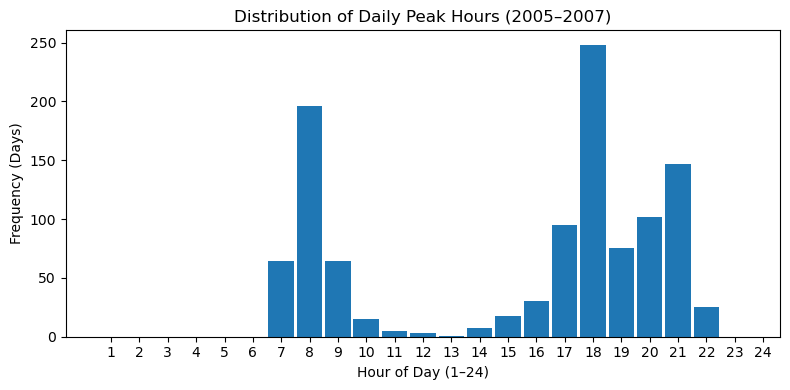

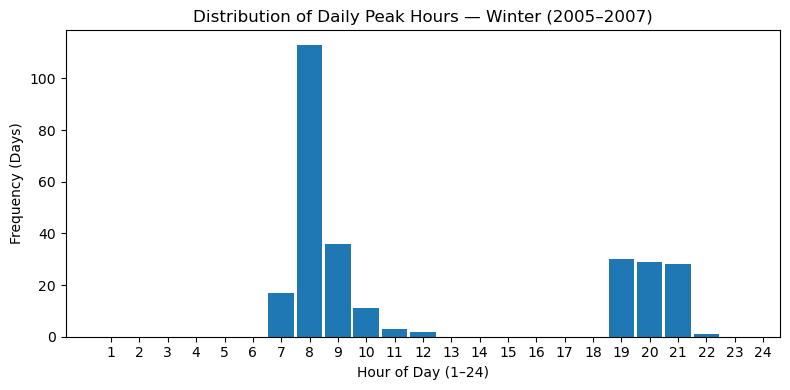

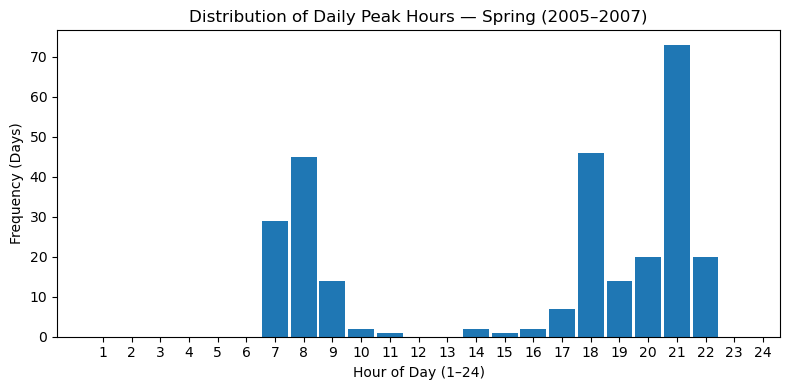

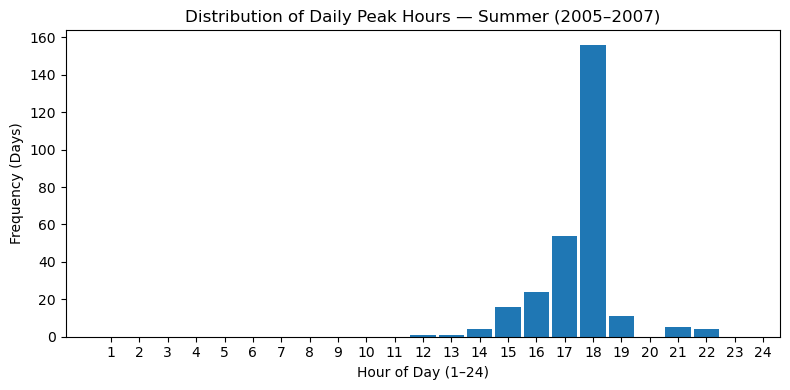

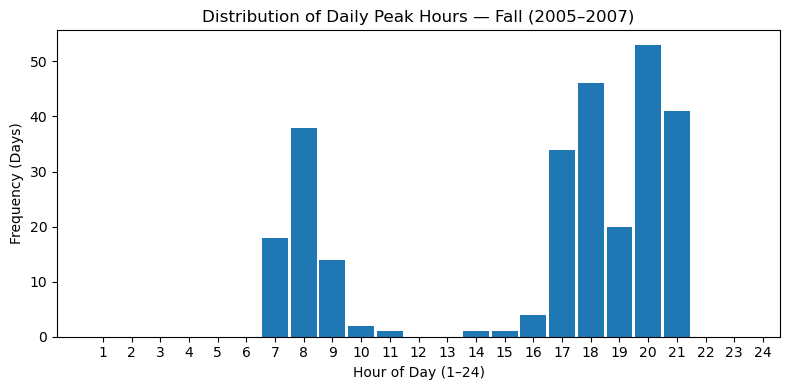

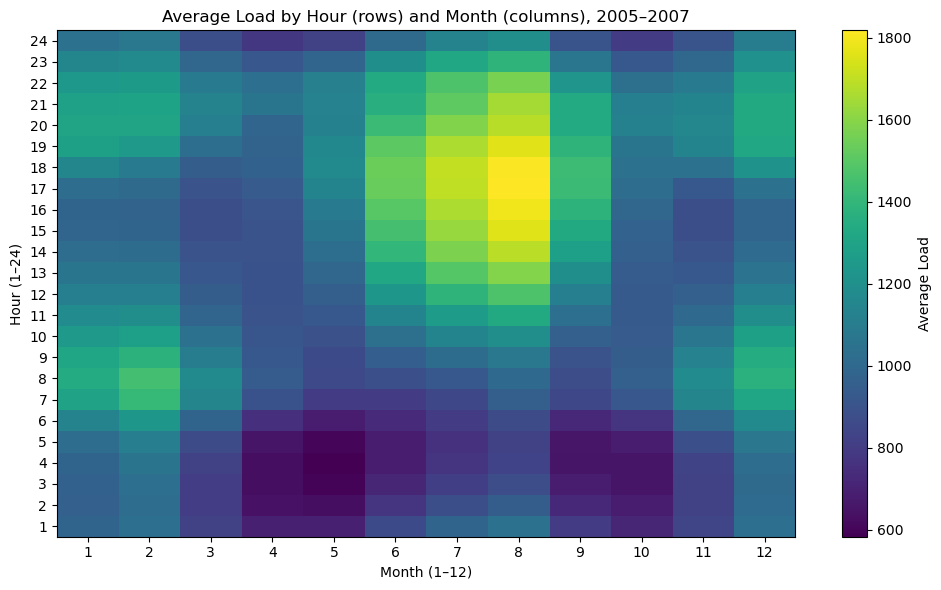

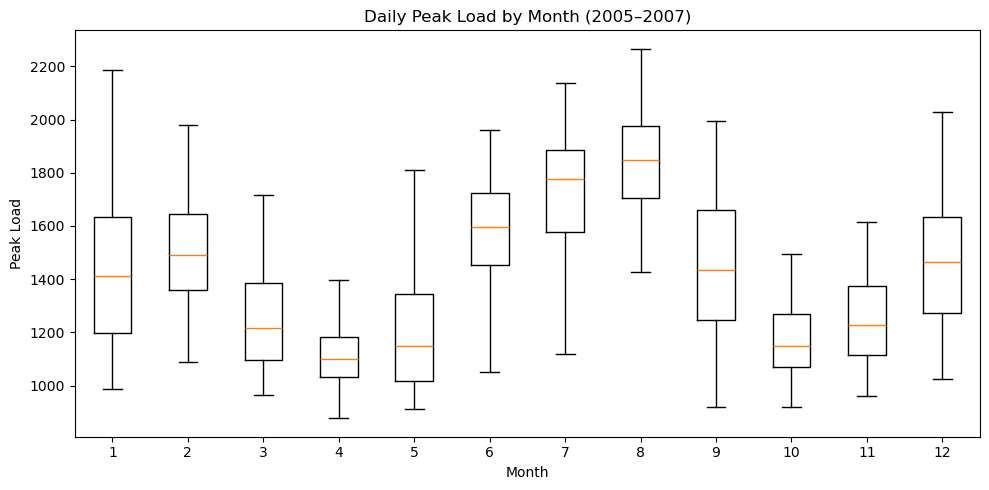

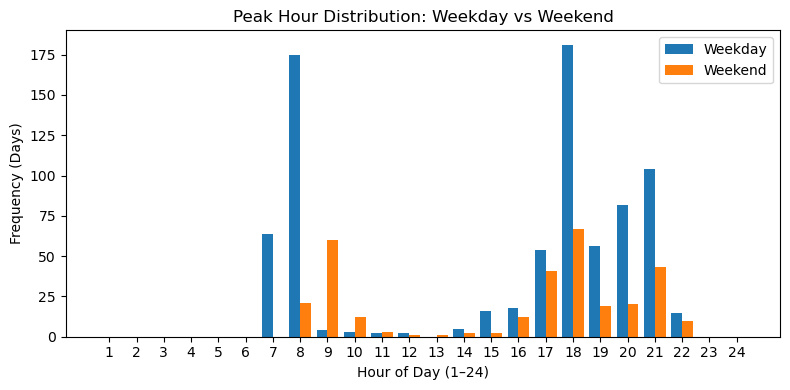

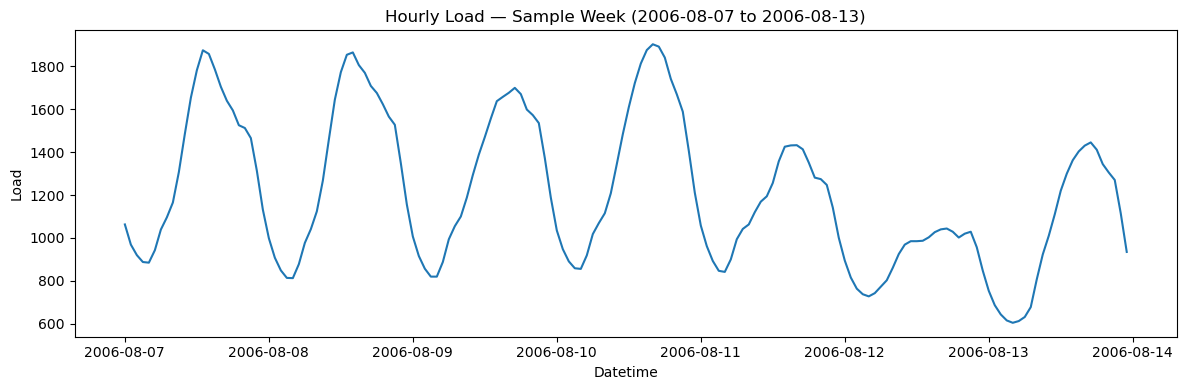

In [14]:
# ---- Plots ----
# 1) Histogram of daily peak hours (overall)
plt.figure(figsize=(8,4))
plt.hist(daily_peaks["PeakHour"], bins=np.arange(0.5, 24.5, 1), rwidth=0.9)
plt.title("Distribution of Daily Peak Hours (2005–2007)")
plt.xlabel("Hour of Day (1–24)")
plt.ylabel("Frequency (Days)")
plt.xticks(range(1,25))
plt.tight_layout()
plt.show()

# 2) Histogram of daily peak hours by season (one chart per season)
for season in ["Winter", "Spring", "Summer", "Fall"]:
    subset = daily_peaks[daily_peaks["Season"] == season]
    plt.figure(figsize=(8,4))
    plt.hist(subset["PeakHour"], bins=np.arange(0.5, 24.5, 1), rwidth=0.9)
    plt.title(f"Distribution of Daily Peak Hours — {season} (2005–2007)")
    plt.xlabel("Hour of Day (1–24)")
    plt.ylabel("Frequency (Days)")
    plt.xticks(range(1,25))
    plt.tight_layout()
    plt.show()

# 3) Heatmap of average load by hour vs month (24 x 12)
plt.figure(figsize=(10,6))
plt.imshow(avg_load_hour_month.values, aspect="auto", origin="lower")
plt.title("Average Load by Hour (rows) and Month (columns), 2005–2007")
plt.xlabel("Month (1–12)")
plt.ylabel("Hour (1–24)")
plt.xticks(ticks=np.arange(0,12), labels=[str(m) for m in range(1,13)])
plt.yticks(ticks=np.arange(0,24), labels=[str(h) for h in range(1,25)])
plt.colorbar(label="Average Load")
plt.tight_layout()
plt.show()

# 4) Boxplot of daily peak load by month
plt.figure(figsize=(10,5))
data_to_plot = [daily_peaks.loc[daily_peaks["Month"]==m, "PeakLoad"].values for m in range(1,13)]
plt.boxplot(data_to_plot, showfliers=False)
plt.title("Daily Peak Load by Month (2005–2007)")
plt.xlabel("Month")
plt.ylabel("Peak Load")
plt.xticks(range(1,13), [str(m) for m in range(1,13)])
plt.tight_layout()
plt.show()

# 5) Weekday vs Weekend: peak hour distribution
plt.figure(figsize=(8,4))
weekday_hours = daily_peaks.loc[~daily_peaks["IsWeekend"], "PeakHour"]
weekend_hours = daily_peaks.loc[daily_peaks["IsWeekend"], "PeakHour"]
# Build aligned hist counts for bar plot
bins = np.arange(1,26,1)
weekday_hist, _ = np.histogram(weekday_hours, bins=bins)
weekend_hist, _ = np.histogram(weekend_hours, bins=bins)
hours = np.arange(1,25)
width = 0.4
plt.bar(hours - width/2, weekday_hist, width=width, label="Weekday")
plt.bar(hours + width/2, weekend_hist, width=width, label="Weekend")
plt.title("Peak Hour Distribution: Weekday vs Weekend")
plt.xlabel("Hour of Day (1–24)")
plt.ylabel("Frequency (Days)")
plt.xticks(hours)
plt.legend()
plt.tight_layout()
plt.show()

# 6) Time series: plot a sample week of hourly load (choose a week from 2006-08)
sample_start = pd.Timestamp("2006-08-07")
sample_end = sample_start + pd.Timedelta(days=7)
mask = (load_hist["Date_dt"] >= sample_start) & (load_hist["Date_dt"] < sample_end)
sample_week = load_hist.loc[mask].copy()

# Ensure it's sorted by datetime + hour
sample_week = sample_week.sort_values(["Date_dt", "Hour"])

plt.figure(figsize=(12,4))
# Build a proper datetime index by adding hour offsets (Hour is 1..24, align to hour-1)
sample_week_dt = sample_week["Date_dt"] + pd.to_timedelta(sample_week["Hour"]-1, unit="h")
plt.plot(sample_week_dt.values, sample_week["Load"].values)
plt.title("Hourly Load — Sample Week (2006-08-07 to 2006-08-13)")
plt.xlabel("Datetime")
plt.ylabel("Load")
plt.tight_layout()
plt.show()
